# 🧠 Train YOLO26L-Seg — Brain Tumor Segmentation

Pipeline:
1. Fix PyTorch tương thích CUDA 13.0 + restart kernel
2. Cài đặt môi trường
3. Tải dataset từ Kaggle
4. Convert binary mask → YOLO polygon format
5. Tạo train/val split + dataset.yaml
6. Tải YOLO26L-Seg pretrained
7. Train Phase 1 (freeze backbone)
8. Train Phase 2 (unfreeze toàn bộ)
9. Evaluate + Visualize

## Cell 1 — Fix PyTorch cho CUDA 13.0

> **Chạy cell này đầu tiên, kernel sẽ tự restart.**  
> Sau khi restart, **bỏ qua cell này** và chạy từ Cell 2 xuống.

In [1]:
import subprocess, sys, torch

print(f'PyTorch hiện tại : {torch.__version__}')
print(f'CUDA built with  : {torch.version.cuda}')

# Kiểm tra nhanh GPU có chạy được không
gpu_ok = False
if torch.cuda.is_available():
    try:
        x = torch.tensor([1.0]).cuda()
        _ = x * 2
        gpu_ok = True
        print(f'GPU test : ✅ OK — không cần reinstall')
    except Exception as e:
        print(f'GPU test : ❌ {e}')

if not gpu_ok:
    print('\n🔄 Cài PyTorch nightly (tương thích CUDA 12.8+/13.0)...')
    subprocess.run([
        sys.executable, '-m', 'pip', 'install', '-q', '--pre',
        'torch', 'torchvision', 'torchaudio',
        '--index-url', 'https://download.pytorch.org/whl/nightly/cu128'
    ], check=True)
    print('✅ Cài xong! Kernel sẽ restart...')
    print('⚠️  Sau khi restart: BỎ QUA cell này, chạy từ Cell 2!')
    import IPython
    IPython.Application.instance().kernel.do_shutdown(True)
else:
    print('\n✅ PyTorch đã tương thích, không cần restart. Chạy tiếp Cell 2!')

PyTorch hiện tại : 2.10.0+cu128
CUDA built with  : 12.8
GPU test : ✅ OK — không cần reinstall

✅ PyTorch đã tương thích, không cần restart. Chạy tiếp Cell 2!


## Cell 2 — Cài đặt & Import

In [2]:
!pip install ultralytics kagglehub -q

import os, shutil, random, cv2, yaml
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import pandas as pd
import kagglehub
import torch
from ultralytics import YOLO
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ============================================================
# Detect GPU setup — tự động chọn single GPU, multi-GPU, hoặc CPU
# ============================================================
n_gpu = torch.cuda.device_count()
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.version.cuda}')
print(f'GPU count: {n_gpu}')

if n_gpu == 0:
    DEVICE = 'cpu'
    print('→ Không có GPU, dùng CPU (chậm!)')

elif n_gpu == 1:
    try:
        x = torch.tensor([1.0]).cuda()
        _ = x * 2
        DEVICE = 0
        print(f'GPU 0    : ✅ {torch.cuda.get_device_name(0)}')
        print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
        print('Mode     : Single GPU')
    except Exception as e:
        DEVICE = 'cpu'
        print(f'GPU lỗi  : {e} → fallback CPU')

else:  # n_gpu >= 2
    # Kiểm tra từng GPU
    ok_gpus = []
    for i in range(n_gpu):
        try:
            x = torch.tensor([1.0]).to(f'cuda:{i}')
            _ = x * 2
            vram = torch.cuda.get_device_properties(i).total_memory / 1e9
            ok_gpus.append(i)
            print(f'GPU {i}    : ✅ {torch.cuda.get_device_name(i)}  ({vram:.1f} GB)')
        except Exception as e:
            print(f'GPU {i}    : ❌ {e}')

    if len(ok_gpus) >= 2:
        # Multi-GPU: DEVICE = '0,1' → Ultralytics dùng DDP tự động
        DEVICE = ','.join(str(i) for i in ok_gpus)
        print(f'\nMode     : 🚀 Multi-GPU DDP ({len(ok_gpus)} GPUs)')
        print(f'DEVICE   : "{DEVICE}"')
        print(f'Tổng VRAM: {sum(torch.cuda.get_device_properties(i).total_memory/1e9 for i in ok_gpus):.1f} GB')
    elif len(ok_gpus) == 1:
        DEVICE = ok_gpus[0]
        print(f'\nMode     : Single GPU (GPU {DEVICE})')
    else:
        DEVICE = 'cpu'
        print('→ Tất cả GPU lỗi, fallback CPU')

print(f'\n✅ Setup xong! Sẽ train trên: DEVICE="{DEVICE}"')

# ============================================================
# Tính batch size tối ưu theo số GPU
# Ultralytics DDP tự chia batch đều cho từng GPU:
#   batch=32, 2 GPU → mỗi GPU xử lý 16 ảnh/step
# ============================================================
BASE_BATCH = 16   # batch tối ưu cho 1 GPU 15.6GB với YOLO26L-Seg
if isinstance(DEVICE, str) and ',' in DEVICE:
    N_GPUS = len(DEVICE.split(','))
    BATCH  = BASE_BATCH * N_GPUS   # scale batch theo số GPU
else:
    N_GPUS = 1
    BATCH  = BASE_BATCH

print(f'N_GPUS   : {N_GPUS}')
print(f'BATCH    : {BATCH}  (={BASE_BATCH} × {N_GPUS} GPU)')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 22.2 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires nu

In [3]:
DEVICE

'0,1'

## Cell 3 — Tải dataset từ Kaggle

In [4]:
path = kagglehub.dataset_download("anhxunv/brain-turmor-segment-datasets")
print("Path to dataset files:", path)

DATASET_PATH = Path(path)
IMG_EXTS     = {'.jpg', '.jpeg', '.png', '.bmp'}

def find_dir_recursive(base, candidates, max_depth=4):
    """Tìm thư mục đệ quy qua nhiều lớp subfolder."""
    def _search(p, depth):
        if depth > max_depth:
            return None
        for name in candidates:
            candidate = p / name
            if candidate.exists() and candidate.is_dir():
                if any(f.suffix.lower() in IMG_EXTS for f in candidate.glob('*.*')):
                    return candidate
        for sub in sorted(p.iterdir()):
            if sub.is_dir() and not sub.name.startswith('.'):
                result = _search(sub, depth + 1)
                if result:
                    return result
        return None
    return _search(base, 0)

IMAGE_DIR = find_dir_recursive(DATASET_PATH, ['image','images','img','Images'])
MASK_DIR  = find_dir_recursive(DATASET_PATH, ['mask','masks','label','labels','Mask'])

image_files = sorted([f for f in IMAGE_DIR.glob('*.*') if f.suffix.lower() in IMG_EXTS])
mask_files  = sorted([f for f in MASK_DIR.glob('*.*')  if f.suffix.lower() in IMG_EXTS])

print(f'IMAGE_DIR : {IMAGE_DIR}  ({len(image_files)} files)')
print(f'MASK_DIR  : {MASK_DIR}  ({len(mask_files)} files)')
print('✅ Tải dataset xong!')

Path to dataset files: /kaggle/input/datasets/anhxunv/brain-turmor-segment-datasets
IMAGE_DIR : /kaggle/input/datasets/anhxunv/brain-turmor-segment-datasets/datasets/image  (5706 files)
MASK_DIR  : /kaggle/input/datasets/anhxunv/brain-turmor-segment-datasets/datasets/mask  (5706 files)
✅ Tải dataset xong!


## Cell 4 — Convert Binary Mask → YOLO Polygon Format

YOLO segmentation cần label dạng:
```
class_id  x1 y1  x2 y2  x3 y3 ...  (normalize 0-1)
0         0.45 0.32  0.48 0.30 ...  ← class 0 = tumor
```
Pipeline: `binary mask (0/255)` → `cv2.findContours` → `polygon` → `normalize`

In [5]:
# Config đường dẫn output
WORK_DIR  = Path('/kaggle/working/brain_tumor_yolo')
TRAIN_IMG = WORK_DIR / 'images' / 'train'
TRAIN_LBL = WORK_DIR / 'labels' / 'train'
VAL_IMG   = WORK_DIR / 'images' / 'val'
VAL_LBL   = WORK_DIR / 'labels' / 'val'

for d in [TRAIN_IMG, TRAIN_LBL, VAL_IMG, VAL_LBL]:
    d.mkdir(parents=True, exist_ok=True)

def mask_to_yolo_polygon(mask_path, epsilon_ratio=0.002):
    """
    Convert 1 binary mask → list dòng YOLO label.
    Trả về [] nếu mask trống.
    """
    mask_np = np.array(Image.open(mask_path).convert('L'))
    H, W    = mask_np.shape

    _, binary = cv2.threshold(mask_np, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return []

    lines = []
    for contour in contours:
        if cv2.contourArea(contour) < 10:   # bỏ noise
            continue
        epsilon = epsilon_ratio * cv2.arcLength(contour, True)
        approx  = cv2.approxPolyDP(contour, epsilon, True)
        if len(approx) < 3:
            continue
        pts  = approx.reshape(-1, 2)
        norm = np.clip(pts / np.array([W, H], dtype=np.float32), 0.0, 1.0)
        coords = ' '.join(f'{x:.6f} {y:.6f}' for x, y in norm)
        lines.append(f'0 {coords}')         # class 0 = tumor
    return lines


# Test thử 1 mask
sample_lines = mask_to_yolo_polygon(mask_files[0])
n_pts = (len(sample_lines[0].split()) - 1) // 2 if sample_lines else 0
print(f'Test mask    : {mask_files[0].name}')
print(f'Số polygon   : {len(sample_lines)}')
print(f'Số điểm/poly : {n_pts}')
print(f'Preview      : {sample_lines[0][:80]}...' if sample_lines else 'Mask trống!')
print('✅ Hàm convert OK!')

Test mask    : 1.png
Số polygon   : 1
Số điểm/poly : 33
Preview      : 0 0.707031 0.345703 0.681641 0.343750 0.658203 0.355469 0.619141 0.380859 0.5644...
✅ Hàm convert OK!


## Cell 5 — Train/Val Split + Convert toàn bộ dataset

In [6]:
# Train/Val split 80/20
image_stems = sorted({f.stem for f in image_files})
random.shuffle(image_stems)
n_val       = int(len(image_stems) * 0.2)
val_stems   = set(image_stems[:n_val])
train_stems = set(image_stems[n_val:])

print(f'Train : {len(train_stems)} ảnh')
print(f'Val   : {len(val_stems)} ảnh')

# Build lookup
stem_to_img  = {f.stem: f for f in image_files}
stem_to_mask = {f.stem: f for f in mask_files}

skipped, converted = [], 0

for stem in tqdm(list(train_stems | val_stems), desc='Converting'):
    if stem not in stem_to_img or stem not in stem_to_mask:
        continue

    yolo_lines = mask_to_yolo_polygon(stem_to_mask[stem])
    if not yolo_lines:
        skipped.append(stem)
        continue

    is_val  = stem in val_stems
    dst_img = VAL_IMG  if is_val else TRAIN_IMG
    dst_lbl = VAL_LBL  if is_val else TRAIN_LBL

    shutil.copy2(stem_to_img[stem], dst_img / stem_to_img[stem].name)
    with open(dst_lbl / f'{stem}.txt', 'w') as f:
        f.write('\n'.join(yolo_lines))
    converted += 1

print(f'\n✅ Convert xong!')
print(f'  Train : {len(list(TRAIN_IMG.glob("*.*")))} ảnh')
print(f'  Val   : {len(list(VAL_IMG.glob("*.*")))} ảnh')
print(f'  Bỏ qua (mask trống): {len(skipped)}')

Train : 4565 ảnh
Val   : 1141 ảnh


Converting: 100%|██████████| 5706/5706 [01:01<00:00, 93.43it/s] 


✅ Convert xong!
  Train : 4565 ảnh
  Val   : 1141 ảnh
  Bỏ qua (mask trống): 0


## Cell 6 — Kiểm tra trực quan label sau convert

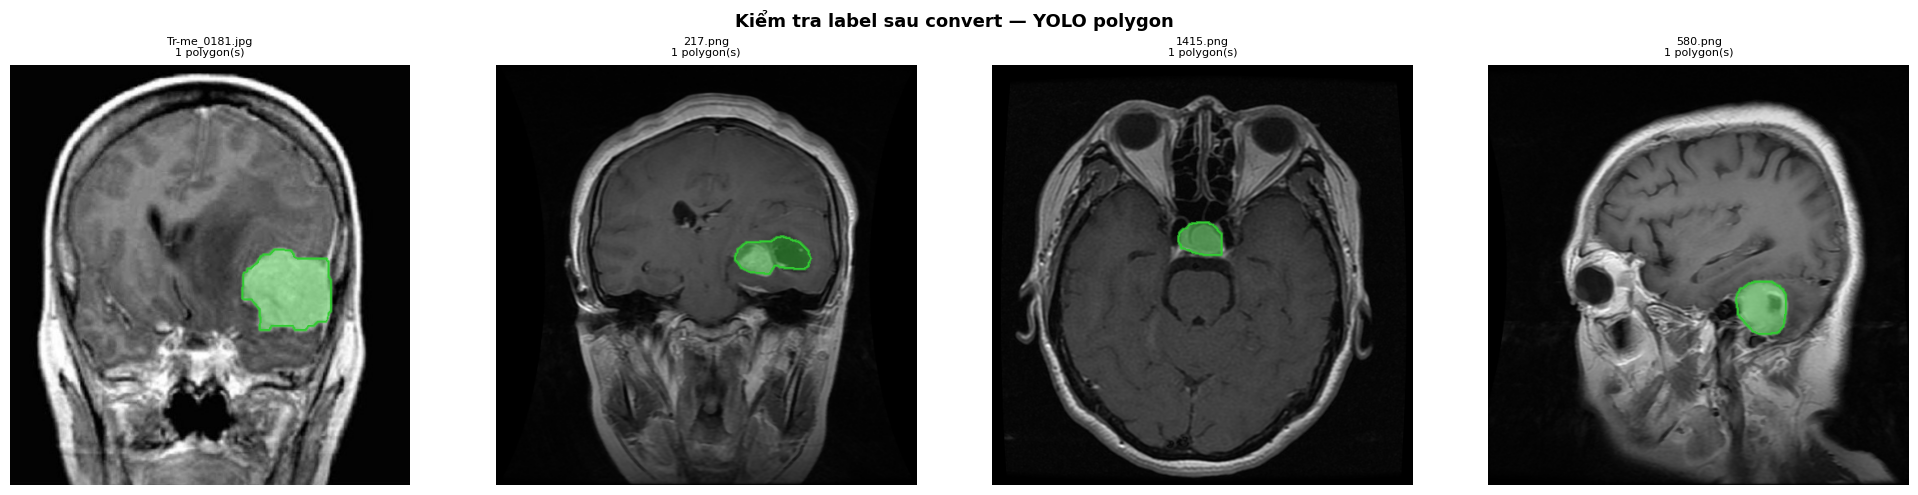

In [7]:
def draw_yolo_seg(img_path, label_path):
    img     = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    H, W    = img.shape[:2]
    overlay = img.copy()
    if not label_path.exists():
        return img
    for line in open(label_path).read().strip().split('\n'):
        parts = line.strip().split()
        pts   = np.array(list(map(float, parts[1:]))).reshape(-1, 2)
        pts[:, 0] *= W; pts[:, 1] *= H
        pts   = pts.astype(np.int32)
        cv2.fillPoly(overlay, [pts], (50, 205, 50))
        cv2.polylines(img, [pts], True, (50, 205, 50), 2)
    return cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

samples = random.sample(list(TRAIN_IMG.glob('*.*')), 4)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Kiểm tra label sau convert — YOLO polygon', fontsize=13, fontweight='bold')
for ax, p in zip(axes, samples):
    lbl = TRAIN_LBL / f'{p.stem}.txt'
    ax.imshow(draw_yolo_seg(p, lbl))
    n = len(open(lbl).readlines()) if lbl.exists() else 0
    ax.set_title(f'{p.name}\n{n} polygon(s)', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Cell 7 — Tạo dataset.yaml

In [8]:
YAML_PATH = WORK_DIR / 'brain_tumor.yaml'
yaml_content = {
    'path'  : str(WORK_DIR),
    'train' : 'images/train',
    'val'   : 'images/val',
    'nc'    : 1,
    'names' : {0: 'tumor'}
}
with open(YAML_PATH, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False, allow_unicode=True)

print('dataset.yaml:')
print('-' * 30)
print(open(YAML_PATH).read())

dataset.yaml:
------------------------------
names:
  0: tumor
nc: 1
path: /kaggle/working/brain_tumor_yolo
train: images/train
val: images/val



## Cell 8 — Tải YOLO26L-Seg Pretrained

In [9]:
# Ultralytics tự tải về cache lần đầu, lần sau dùng lại
model = YOLO('yolo26l-seg.pt')

total  = sum(p.numel() for p in model.parameters())
print(f'Model  : {model.model.__class__.__name__}')
print(f'Task   : {model.task}')
print(f'Params : {total/1e6:.1f}M')
print('✅ Load model xong!')

Model  : SegmentationModel
Task   : segment
Params : 31.5M
✅ Load model xong!


## Cell 9 — Train Phase 1: Freeze Backbone (layer 0-9, 15 epochs)

Head + Neck đang reset về 1 class → gradient lớn có thể phá backbone pretrained.  
→ Freeze backbone để head ổn định trước, lr cao hơn.

In [13]:
results_phase1 = model.train(
    # Data
    data         = str(YAML_PATH),
    imgsz        = 640,
    batch        = 48,
    device       = DEVICE,
    workers      = 2,

    # Phase 1
    epochs       = 25,
    freeze       = 10,          # freeze layer 0-9 (toàn backbone)

    # Optimizer
    optimizer    = 'auto',      # tự dùng MuSGD
    lr0          = 0.001,       # lr cao hơn vì chỉ train head/neck
    lrf          = 0.1,
    momentum     = 0.95,
    weight_decay = 0.00027,
    warmup_epochs= 2.0,

    # Augmentation nhẹ cho phase 1
    hsv_h        = 0.01,        # MRI grayscale — giảm color aug
    hsv_s        = 0.3,
    hsv_v        = 0.3,
    flipud       = 0.5,         # flip dọc hợp lý với MRI não
    fliplr       = 0.5,
    degrees      = 5.0,
    mosaic       = 0.5,
    mixup        = 0.0,
    copy_paste   = 0.1,
    close_mosaic = 3,

    # Saving
    project      = '/kaggle/working/runs',
    name         = 'phase1_freeze',
    save         = True,
    save_period  = 5,
    val          = True,
    plots        = True,
)

best_p1 = Path(results_phase1.save_dir) / 'weights' / 'best.pt'
print(f'\n✅ Phase 1 xong!')
print(f'   Best checkpoint: {best_p1}')

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=48, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=3, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/brain_tumor_yolo/brain_tumor.yaml, degrees=5.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.01, hsv_s=0.3, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26l-seg.pt, momentum=0.95, mosaic=0.5, multi_scale=0.0, name=p

AttributeError: 'NoneType' object has no attribute 'save_dir'

In [17]:
from ultralytics import YOLO
from pathlib import Path

candidates = [
    Path('/kaggle/working/runs/phase1_freeze-4/weights/best.pt'),  # 63.4 MB — nghi ngờ
    Path('/kaggle/working/runs/phase1_freeze-2/weights/best.pt'),  # 183.8 MB
    Path('/kaggle/working/runs/phase1_freeze/weights/best.pt'),    # 183.8 MB
]

print("🔍 Kiểm tra từng checkpoint...\n")
valid = []

for pt in candidates:
    size_mb = pt.stat().st_size / 1e6
    try:
        m    = YOLO(str(pt))
        info = m.info(verbose=False)
        n_params = sum(p.numel() for p in m.parameters()) / 1e6
        print(f"✅ {pt.parent.parent.name}  ({size_mb:.1f} MB)")
        print(f"   Params : {n_params:.1f}M")
        print(f"   Task   : {m.task}")
        valid.append((pt, size_mb, n_params))
    except Exception as e:
        print(f"❌ {pt.parent.parent.name}  ({size_mb:.1f} MB)")
        print(f"   Lỗi   : {e}")
    print()

# Chọn checkpoint tốt nhất
# Ưu tiên: load được + params đầy đủ (~43M) + mới nhất
if valid:
    # Sort theo params nhiều nhất (đầy đủ nhất) rồi mới nhất
    valid.sort(key=lambda x: x[2], reverse=True)
    best_p1 = valid[0][0]
    print(f"→ Dùng checkpoint: {best_p1}")
    print(f"   Size  : {valid[0][1]:.1f} MB")
    print(f"   Params: {valid[0][2]:.1f}M")

🔍 Kiểm tra từng checkpoint...

✅ phase1_freeze-4  (63.4 MB)
   Params : 31.4M
   Task   : segment

✅ phase1_freeze-2  (183.8 MB)
   Params : 31.4M
   Task   : segment

✅ phase1_freeze  (183.8 MB)
   Params : 31.4M
   Task   : segment

→ Dùng checkpoint: /kaggle/working/runs/phase1_freeze-4/weights/best.pt
   Size  : 63.4 MB
   Params: 31.4M


In [18]:
# ============================================================
# 📊 Đo FLOPs, Params, Latency — inference 1 sample
# ============================================================
from ultralytics.utils.torch_utils import get_flops, get_num_params
import time, torch, numpy as np

def profile_model(model_path, imgsz=640, device=DEVICE, n_warmup=10, n_runs=100):
    """
    Đo toàn diện một YOLO model:
      - FLOPs (GFLOPs)    : số phép tính floating point mỗi forward pass
      - Params (M)        : tổng số tham số
      - Latency (ms)      : thời gian inference 1 ảnh
      - Throughput (FPS)  : số ảnh xử lý được mỗi giây

    Args:
        model_path : đường dẫn file .pt
        imgsz      : kích thước ảnh input
        device     : 0 (GPU) hoặc 'cpu'
        n_warmup   : số lần warmup trước khi đo (GPU cần warmup)
        n_runs     : số lần đo để lấy trung bình
    """
    print(f'\n{'='*55}')
    print(f'  🔬 Model Profile: {Path(model_path).name}')
    print(f'{'='*55}')

    m = YOLO(str(model_path))
    pytorch_model = m.model

    # --- Params ---
    total_params    = get_num_params(pytorch_model)
    trainable_params = sum(p.numel() for p in pytorch_model.parameters() if p.requires_grad)
    print(f'  Params total     : {total_params/1e6:.2f} M')
    print(f'  Params trainable : {trainable_params/1e6:.2f} M')
    print(f'  Params frozen    : {(total_params - trainable_params)/1e6:.2f} M')

    # --- FLOPs ---
    # get_flops tính GFLOPs cho 1 forward pass với input imgsz
    try:
        gflops = get_flops(pytorch_model, imgsz=imgsz)
        print(f'  FLOPs (GFLOPs)   : {gflops:.2f} G')
        print(f'  FLOPs (TFLOPs)   : {gflops/1000:.4f} T')
    except Exception as e:
        print(f'  FLOPs            : N/A ({e})')

    # --- Latency & Throughput ---
    dev    = torch.device(f'cuda:{device}' if isinstance(device, int) else device)
    dummy  = torch.randn(1, 3, imgsz, imgsz).to(dev)
    pytorch_model = pytorch_model.to(dev).eval()

    # Warmup — GPU cần vài lần chạy đầu để ổn định
    print(f'\n  Warmup {n_warmup} lần...', end=' ')
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = pytorch_model(dummy)
    if dev.type == 'cuda':
        torch.cuda.synchronize()
    print('done')

    # Đo latency
    latencies = []
    with torch.no_grad():
        for _ in range(n_runs):
            if dev.type == 'cuda':
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            _  = pytorch_model(dummy)
            if dev.type == 'cuda':
                torch.cuda.synchronize()
            latencies.append((time.perf_counter() - t0) * 1000)  # ms

    lat_mean = np.mean(latencies)
    lat_std  = np.std(latencies)
    lat_min  = np.min(latencies)
    lat_max  = np.max(latencies)
    fps      = 1000 / lat_mean

    print(f'\n  Latency ({n_runs} runs, batch=1, imgsz={imgsz}):')
    print(f'    Mean ± Std : {lat_mean:.2f} ± {lat_std:.2f} ms')
    print(f'    Min        : {lat_min:.2f} ms')
    print(f'    Max        : {lat_max:.2f} ms')
    print(f'  Throughput   : {fps:.1f} FPS  (batch=1)')

    # --- Latency histogram ---
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(latencies, bins=30, color='steelblue', edgecolor='white')
    ax.axvline(lat_mean, color='red',    linestyle='--', label=f'mean={lat_mean:.1f}ms')
    ax.axvline(lat_min,  color='green',  linestyle=':',  label=f'min={lat_min:.1f}ms')
    ax.set_title(f'Latency distribution — {Path(model_path).name}')
    ax.set_xlabel('Latency (ms)'); ax.set_ylabel('Count')
    ax.legend(); plt.tight_layout(); plt.show()

    return {
        'params_M'   : total_params / 1e6,
        'gflops'     : gflops if 'gflops' in dir() else None,
        'lat_mean_ms': lat_mean,
        'lat_std_ms' : lat_std,
        'fps'        : fps,
    }


# Đo model sau Phase 1
stats_p1 = profile_model(best_p1, imgsz=640, device=DEVICE)


  🔬 Model Profile: best.pt
  Params total     : 31.37 M
  Params trainable : 0.00 M
  Params frozen    : 31.37 M
  FLOPs (GFLOPs)   : 150.26 G
  FLOPs (TFLOPs)   : 0.1503 T


RuntimeError: Invalid device string: '0,1'

## Cell 10 — Train Phase 2: Unfreeze toàn bộ (45 epochs)

Head đã ổn định → mở backbone ra fine-tune sâu với lr nhỏ theo paper YOLO26L.

In [ ]:
# Dùng checkpoint mới nhất từ phase 1
best_p1 = Path('/kaggle/working/runs/phase1_freeze-4/weights/best.pt')
print(f'✅ best_p1 = {best_p1}')

# Load và chạy Phase 2 luôn
model_p2 = YOLO(str(best_p1))

results_phase2 = model_p2.train(
    # Data
    data         = str(YAML_PATH),
    imgsz        = 640,
    batch        = 32,
    device       = DEVICE,
    workers      = 2,

    # Phase 2
    epochs       = 45,
    freeze       = 0,           # unfreeze toàn bộ

    # Optimizer theo paper YOLO26L COCO fine-tune
    optimizer    = 'auto',
    lr0          = 0.00038,
    lrf          = 0.88,
    momentum     = 0.95,
    weight_decay = 0.00027,
    warmup_epochs= 1.0,

    # Augmentation mạnh hơn phase 1
    hsv_h        = 0.01,
    hsv_s        = 0.3,
    hsv_v        = 0.3,
    flipud       = 0.5,
    fliplr       = 0.5,
    degrees      = 5.0,
    mosaic       = 1.0,
    mixup        = 0.10,
    copy_paste   = 0.30,
    close_mosaic = 10,          # tắt mosaic 10 epoch cuối

    # Saving
    project      = '/kaggle/working/runs',
    name         = 'phase2_unfreeze',
    save         = True,
    save_period  = 5,
    val          = True,
    plots        = True,
)

best_p2 = Path(results_phase2.save_dir) / 'weights' / 'best.pt'
print(f'\n✅ Phase 2 xong!')
print(f'   Best checkpoint: {best_p2}')

✅ best_p1 = /kaggle/working/runs/phase1_freeze-4/weights/best.pt
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/brain_tumor_yolo/brain_tumor.yaml, degrees=5.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=45, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.01, hsv_s=0.3, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00038, lrf=0.88, mask_ratio=4, max_det=300, mixup=0.1, mode=train, mode

In [ ]:
!echo aa 

In [ ]:
# ============================================================
# 📊 Đo Phase 2 + Pretrained → So sánh 3 model
# Chạy cell này SAU KHI train phase 2 xong
# profile_model() đã được định nghĩa ở cell trên
# ============================================================

# --- Đo Phase 2 ---
print('📌 Đo Phase 2 (full fine-tuned)...')
stats_p2 = profile_model(best_p2, imgsz=640)

# --- Đo Pretrained gốc (COCO 80 class) để so sánh baseline ---
print('\n📌 Đo Pretrained gốc (COCO)...')
stats_pre = profile_model('yolo26l-seg.pt', imgsz=640)

# ============================================================
# Bảng so sánh 3 model
# ============================================================
print('\n' + '='*70)
print(f'  {"Chỉ số":<22} {"Pretrained":>14} {"Phase 1":>14} {"Phase 2":>14}')
print('='*70)

rows = [
    ('Params total (M)',    'params_M',    '{:.2f}'),
    ('Params trainable (M)','trainable_M', '{:.2f}'),
    ('Params frozen (M)',   'frozen_M',    '{:.2f}'),
    ('FLOPs (GFLOPs)',      'gflops',      '{:.2f}'),
    ('Latency mean (ms)',   'lat_mean_ms', '{:.2f}'),
    ('Latency std (ms)',    'lat_std_ms',  '{:.2f}'),
    ('Throughput (FPS)',    'fps',         '{:.1f}'),
]

for label, key, fmt in rows:
    v_pre = stats_pre.get(key)
    v_p1  = stats_p1.get(key)
    v_p2  = stats_p2.get(key)

    def fmt_val(v):
        return fmt.format(v) if v is not None else 'N/A'

    print(f'  {label:<22} {fmt_val(v_pre):>14} {fmt_val(v_p1):>14} {fmt_val(v_p2):>14}')

print('='*70)
print()
print('  💡 Params & FLOPs không đổi → architecture giữ nguyên')
print('  💡 Latency thay đổi nhẹ do weight distribution sau training')

# ============================================================
# Bar charts so sánh trực quan
# ============================================================
labels   = ['Pretrained\n(COCO)', 'Phase 1\n(freeze)', 'Phase 2\n(unfreeze)']
colors   = ['#888888', '#4a9eff', '#4ade80']

metrics_to_plot = [
    ('Latency mean (ms)\nlower is better',  'lat_mean_ms', False),
    ('Throughput (FPS)\nhigher is better',  'fps',         True),
    ('FLOPs (GFLOPs)\nlower is better',     'gflops',      False),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'So sánh Pretrained vs Phase 1 vs Phase 2',
    fontsize=14, fontweight='bold'
)

for ax, (title, key, higher_better) in zip(axes, metrics_to_plot):
    vals = [
        stats_pre.get(key) or 0,
        stats_p1.get(key)  or 0,
        stats_p2.get(key)  or 0,
    ]
    bars = ax.bar(labels, vals, color=colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=11)

    # Label giá trị trên mỗi bar
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(vals) * 0.02,
            f'{val:.1f}',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold'
        )

    # Highlight bar tốt nhất
    best_idx = vals.index(max(vals) if higher_better else min(vals))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)

    ax.set_ylim(0, max(vals) * 1.18)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

# ============================================================
# Tóm tắt speedup Phase 2 so với Pretrained
# ============================================================
if stats_pre['lat_mean_ms'] and stats_p2['lat_mean_ms']:
    speedup = stats_pre['lat_mean_ms'] / stats_p2['lat_mean_ms']
    fps_gain = stats_p2['fps'] - stats_pre['fps']
    print(f'\n📈 So sánh Phase 2 vs Pretrained:')
    print(f'   Latency  : {stats_pre["lat_mean_ms"]:.2f}ms → {stats_p2["lat_mean_ms"]:.2f}ms  (x{speedup:.2f})')
    print(f'   FPS gain : {fps_gain:+.1f} FPS')


## Cell 11 — Evaluate: mAP & Mask IoU

In [ ]:
best_model = YOLO(str(best_p2))

metrics = best_model.val(
    data   = str(YAML_PATH),
    imgsz  = 640,
    device = DEVICE,
    plots  = True,
)

print('\n' + '=' * 50)
print('  📊 KẾT QUẢ EVALUATE')
print('=' * 50)
print(f'  mAP50    (box)  : {metrics.box.map50:.4f}')
print(f'  mAP50-95 (box)  : {metrics.box.map:.4f}')
print(f'  mAP50    (mask) : {metrics.seg.map50:.4f}')
print(f'  mAP50-95 (mask) : {metrics.seg.map:.4f}')
print(f'  Precision       : {metrics.box.mp:.4f}')
print(f'  Recall          : {metrics.box.mr:.4f}')

## Cell 12 — Visualize kết quả Predict

In [ ]:
val_imgs     = list(VAL_IMG.glob('*.*'))
sample_imgs  = random.sample(val_imgs, min(6, len(val_imgs)))

preds = best_model.predict(
    source  = sample_imgs,
    imgsz   = 640,
    conf    = 0.25,
    device  = DEVICE,
    verbose = False,
)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Predict — YOLO26L-Seg Brain Tumor', fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, (result, img_path) in enumerate(zip(preds, sample_imgs)):
    vis  = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    n    = len(result.boxes) if result.boxes is not None else 0
    cfgs = result.boxes.conf.cpu().numpy() if n > 0 else []
    cstr = ', '.join([f'{c:.2f}' for c in cfgs]) if len(cfgs) > 0 else 'none'
    axes[idx].imshow(vis)
    axes[idx].set_title(f'{img_path.name}\n{n} det | conf: {cstr}', fontsize=8)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Cell 13 — Learning Curves

In [ ]:
def plot_curves(save_dir, title):
    csv_path = Path(save_dir) / 'results.csv'
    if not csv_path.exists():
        print(f'Không tìm thấy results.csv: {csv_path}')
        return
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for col, color, label in [
        ('train/box_loss', 'steelblue', 'train'),
        ('val/box_loss',   'coral',     'val')
    ]:
        if col in df.columns:
            axes[0].plot(df['epoch'], df[col], color=color, label=label)
    axes[0].set_title('Box Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

    for col, color, label in [
        ('train/seg_loss', 'steelblue', 'train'),
        ('val/seg_loss',   'coral',     'val')
    ]:
        if col in df.columns:
            axes[1].plot(df['epoch'], df[col], color=color, label=label)
    axes[1].set_title('Seg Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

    for col, color, label in [
        ('metrics/mAP50(M)', 'seagreen', 'mAP50 mask'),
        ('metrics/mAP50(B)', 'purple',   'mAP50 box')
    ]:
        if col in df.columns:
            axes[2].plot(df['epoch'], df[col], color=color, label=label)
    axes[2].set_title('mAP50'); axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_curves(results_phase1.save_dir, 'Phase 1 — Freeze Backbone (15 epochs)')
plot_curves(results_phase2.save_dir, 'Phase 2 — Unfreeze All (45 epochs)')

## Cell 14 — Lưu model

In [ ]:
final = Path('/kaggle/working/yolo26l_brain_tumor_best.pt')
shutil.copy2(best_p2, final)

print('=' * 50)
print('  ✅ HOÀN TẤT!')
print('=' * 50)
print(f'  Best model  : {final}')
print(f'  Phase 1 dir : {results_phase1.save_dir}')
print(f'  Phase 2 dir : {results_phase2.save_dir}')
print()
print('  Dùng lại model sau này:')
print("  model = YOLO('yolo26l_brain_tumor_best.pt')")
print("  results = model.predict('scan.jpg', conf=0.25)")